# Análisis Exploratorio de Datos (EDA) - Telemetría Las Bambas
Este notebook realiza el análisis exploratorio interactivo de los datos de telemetría de los camiones.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configurar estilo de gráficos
sns.set_theme(style="whitegrid")

### 1. Carga de Datos

In [2]:
file_path = 'telemetria_bambas_2026_enero.csv'
print(f"Cargando datos desde {file_path}...")
df = pd.read_csv(file_path)

# Convertir timestamp a datetime si existe
if 'timestamp' in df.columns:
    df['timestamp'] = pd.to_datetime(df['timestamp'])

df.head()

Cargando datos desde telemetria_bambas_2026_enero.csv...


,timestamp,id_camion,id_neumatico,posicion,tajo_asignado,estado_operativo,latitud,longitud,condiciones,distancia_chancadora_km,...,presion_psi,temperatura_c,vibracion_g,tkph_real,profundidad_inicial_mm,profundidad_actual_mm,desgaste_mm_h,horas_trabajadas_acumuladas,vida_util_proyectada_horas,cph_actual
0,2026-01-01 00:00:00,CAT_001,N5980-CAT_001-P1,1,Tajo_1 (Tajo Norte),Operando,-14.084418,-72.280544,"Roca 70 MPa, +10% pendiente, sube cargado",4.5,...,112.5,70.9,0.82,6542.8,65.0,64.99,0.00561,1,6201.0,8.39
1,2026-01-01 01:00:00,CAT_001,N5980-CAT_001-P1,1,Tajo_1 (Tajo Norte),Operando,-14.086252,-72.283047,"Roca 70 MPa, +10% pendiente, sube cargado",4.5,...,108.9,65.5,0.86,4560.8,65.0,64.99,0.00769,2,6201.0,8.39
2,2026-01-01 02:00:00,CAT_001,N5980-CAT_001-P1,1,Tajo_1 (Tajo Norte),Operando,-14.086271,-72.283011,"Roca 70 MPa, +10% pendiente, sube cargado",4.5,...,110.4,68.0,1.11,5261.4,65.0,64.98,0.00650,3,6201.0,8.39
3,2026-01-01 03:00:00,CAT_001,N5980-CAT_001-P1,1,Tajo_1 (Tajo Norte),Operando,-14.087246,-72.282758,"Roca 70 MPa, +10% pendiente, sube cargado",4.5,...,110.0,68.7,0.87,5668.7,65.0,64.97,0.00665,4,6201.0,8.39
4,2026-01-01 04:00:00,CAT_001,N5980-CAT_001-P1,1,Tajo_1 (Tajo Norte),Operando,-14.084771,-72.281955,"Roca 70 MPa, +10% pendiente, sube cargado",4.5,...,106.0,64.9,1.77,4246.8,65.0,64.97,0.00543,5,6201.0,8.39


### 2. Información General y Valores Nulos

In [3]:
print("--- Información General ---")
df.info()

--- Información General ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 259560 entries, 0 to 259559
Data columns (total 22 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   timestamp                    259560 non-null  datetime64[ns]
 1   id_camion                    259560 non-null  object        
 2   id_neumatico                 259560 non-null  object        
 3   posicion                     259560 non-null  int64         
 4   tajo_asignado                259560 non-null  object        
 5   estado_operativo             259560 non-null  object        
 6   latitud                      259560 non-null  float64       
 7   longitud                     259560 non-null  float64       
 8   condiciones                  259560 non-null  object        
 9   distancia_chancadora_km      259560 non-null  float64       
 10  payload_ton                  259560 non-null  float64       
 11

In [4]:
print("--- Valores Nulos ---")
df.isnull().sum()

--- Valores Nulos ---


timestamp                      0
id_camion                      0
id_neumatico                   0
posicion                       0
tajo_asignado                  0
estado_operativo               0
latitud                        0
longitud                       0
condiciones                    0
distancia_chancadora_km        0
payload_ton                    0
velocidad_kmh                  0
presion_psi                    0
temperatura_c                  0
vibracion_g                    0
tkph_real                      0
profundidad_inicial_mm         0
profundidad_actual_mm          0
desgaste_mm_h                  0
horas_trabajadas_acumuladas    0
vida_util_proyectada_horas     0
cph_actual                     0
dtype: int64

### 3. Estadísticas Descriptivas

In [5]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
timestamp,259560,2026-01-15 23:59:59.999999744,2026-01-01 00:00:00,2026-01-08 12:00:00,2026-01-16 00:00:00,2026-01-23 12:00:00,2026-01-31 00:00:00,NaN
posicion,259560.0,3.5,1.0,2.0,3.5,5.0,6.0,1.707828
latitud,259560.0,-14.088714,-14.093713,-14.091714,-14.088713,-14.085716,-14.083713,0.003215
longitud,259560.0,-72.283473,-72.286477,-72.284972,-72.283476,-72.281971,-72.280477,0.001732
distancia_chancadora_km,259560.0,4.15,3.8,3.8,4.15,4.5,4.5,0.350001
payload_ton,259560.0,271.97701,0.0,302.1,316.7,328.2,390.7,115.132828
velocidad_kmh,259560.0,22.518662,0.0,20.8,25.6,29.2,48.1,10.440454
presion_psi,259560.0,110.550773,100.0,107.3,110.4,113.8,123.8,3.974419
temperatura_c,259560.0,69.740153,16.8,62.1,66.2,90.3,111.8,22.970029
vibracion_g,259560.0,1.587036,-0.15,0.98,1.44,2.36,5.18,0.969315


### 4. Matriz de Correlación
Analizamos la relación lineal entre todas las variables numéricas.

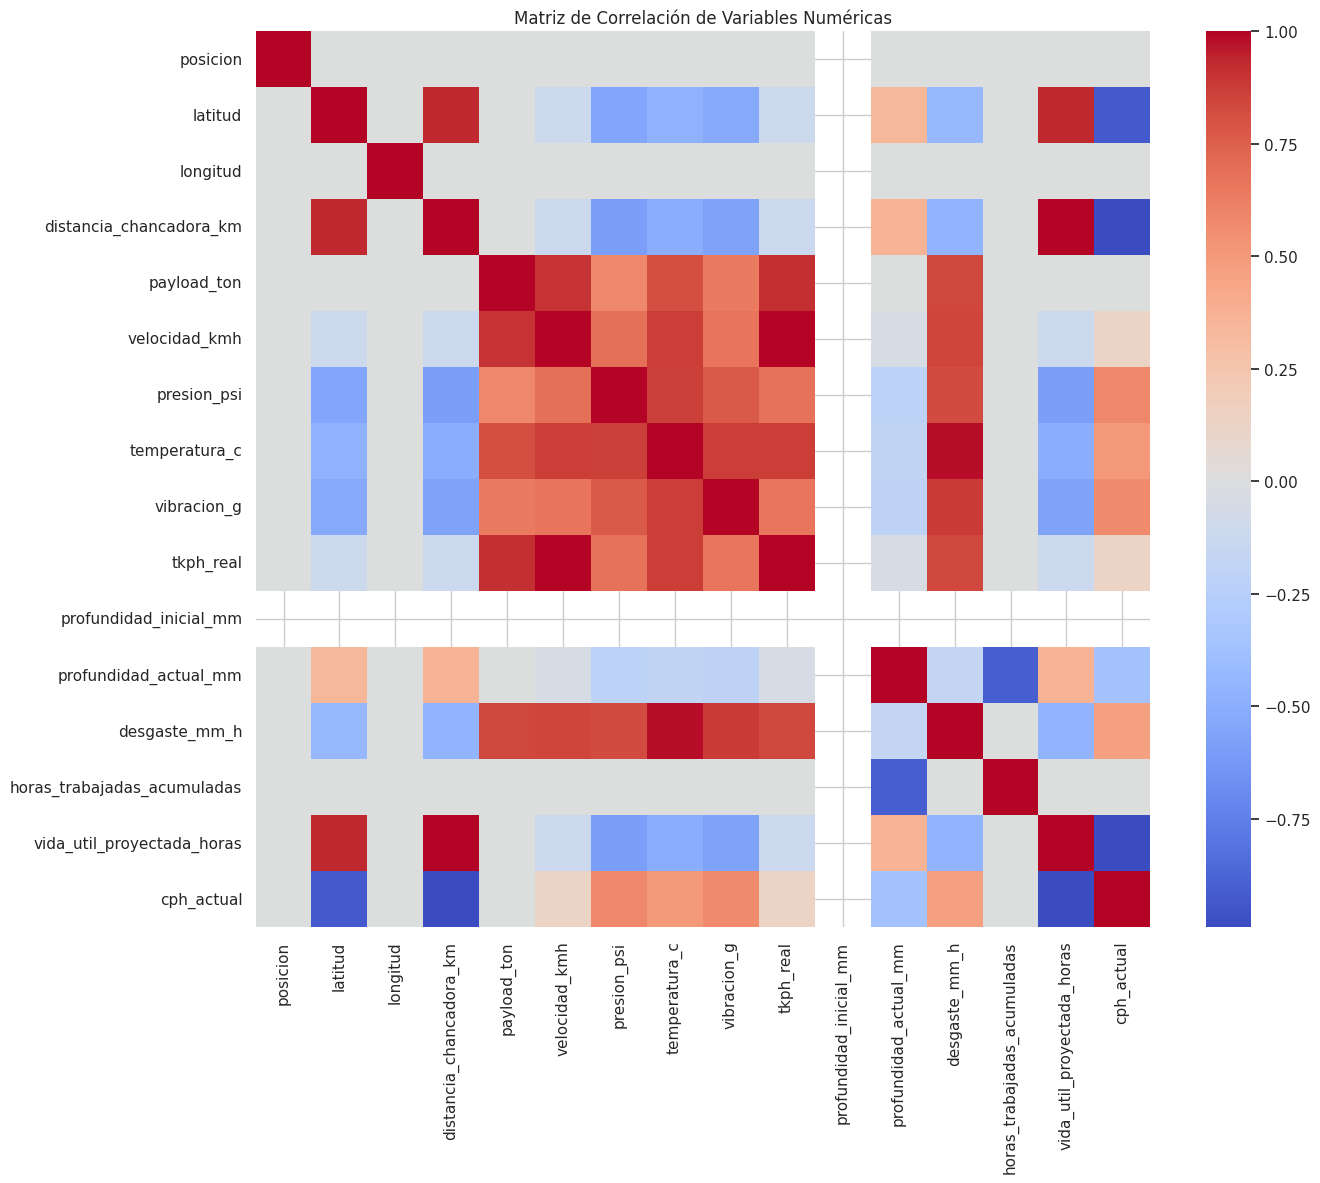

In [6]:
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns

plt.figure(figsize=(14, 12))
corr = df[numerical_cols].corr()
sns.heatmap(corr, annot=False, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación de Variables Numéricas')
plt.tight_layout()
plt.show()

### 5. Distribución de Variables Clave

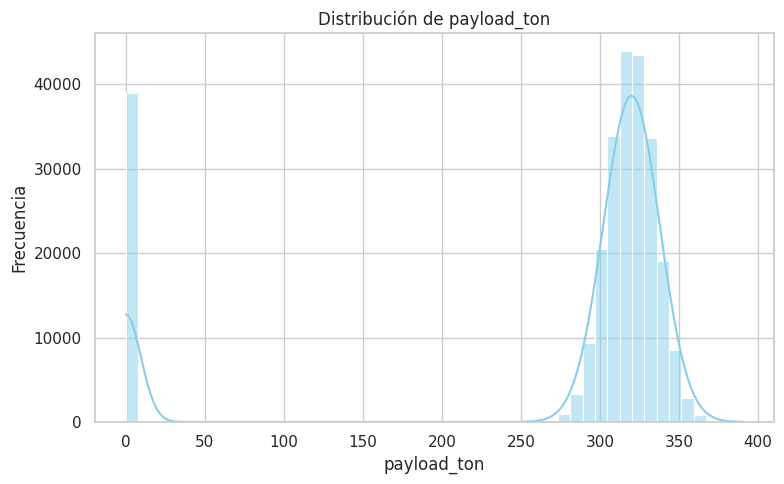

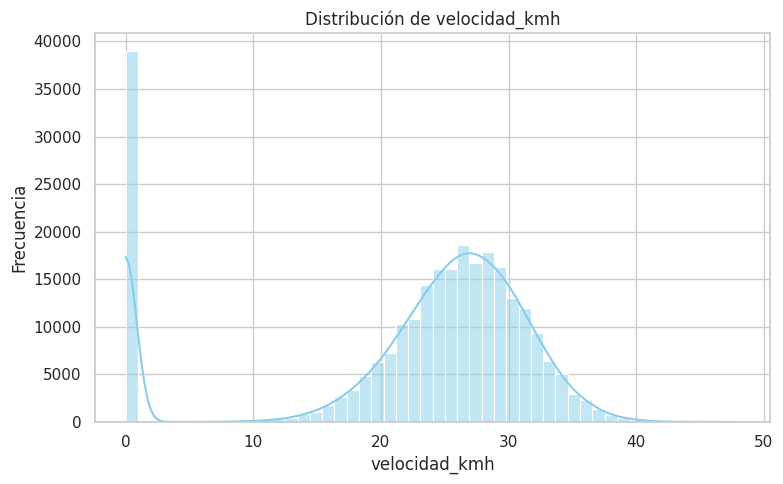

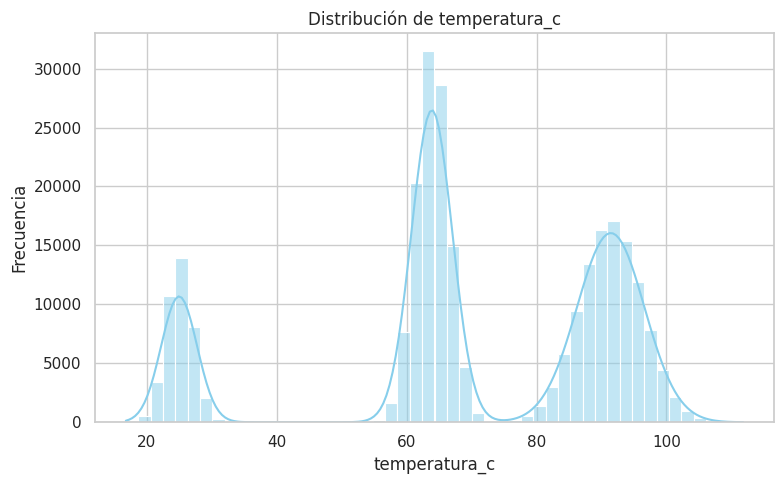

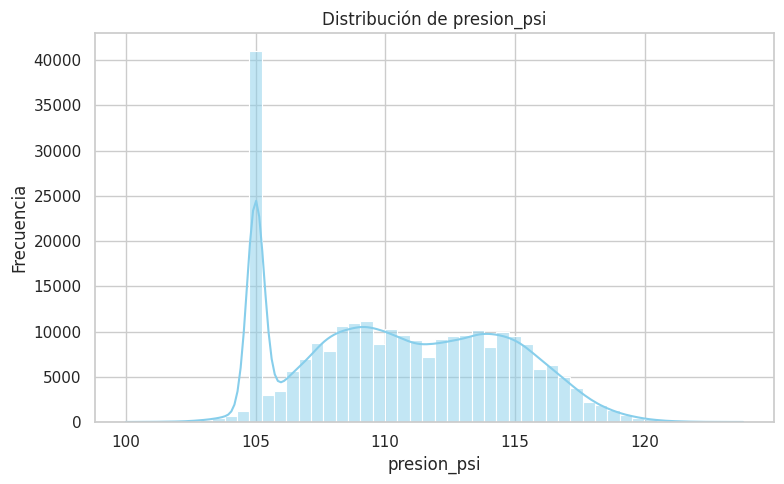

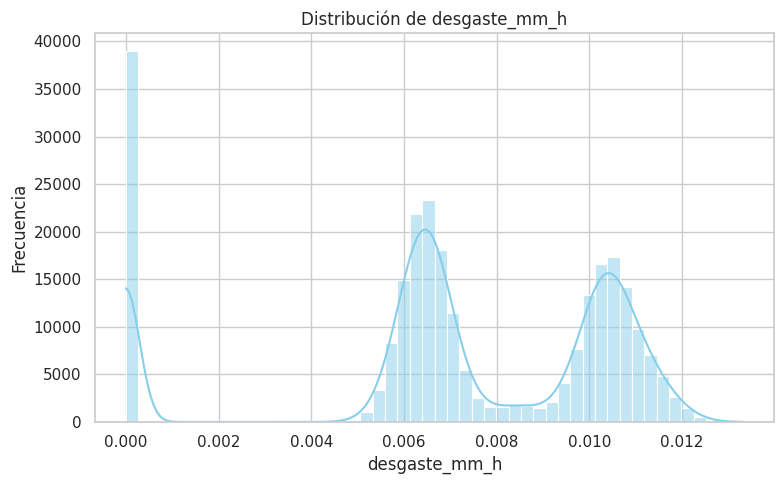

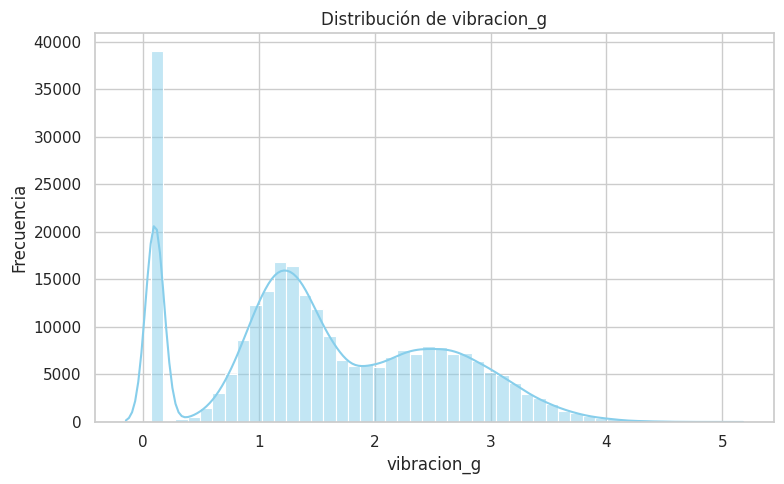

In [7]:
key_vars = ['payload_ton', 'velocidad_kmh', 'temperatura_c', 'presion_psi', 'desgaste_mm_h', 'vibracion_g']
for var in key_vars:
    if var in df.columns:
        plt.figure(figsize=(8, 5))
        sns.histplot(df[var].dropna(), kde=True, bins=50, color='skyblue')
        plt.title(f'Distribución de {var}')
        plt.xlabel(var)
        plt.ylabel('Frecuencia')
        plt.tight_layout()
        plt.show()

### 6. Análisis de Variables Categóricas

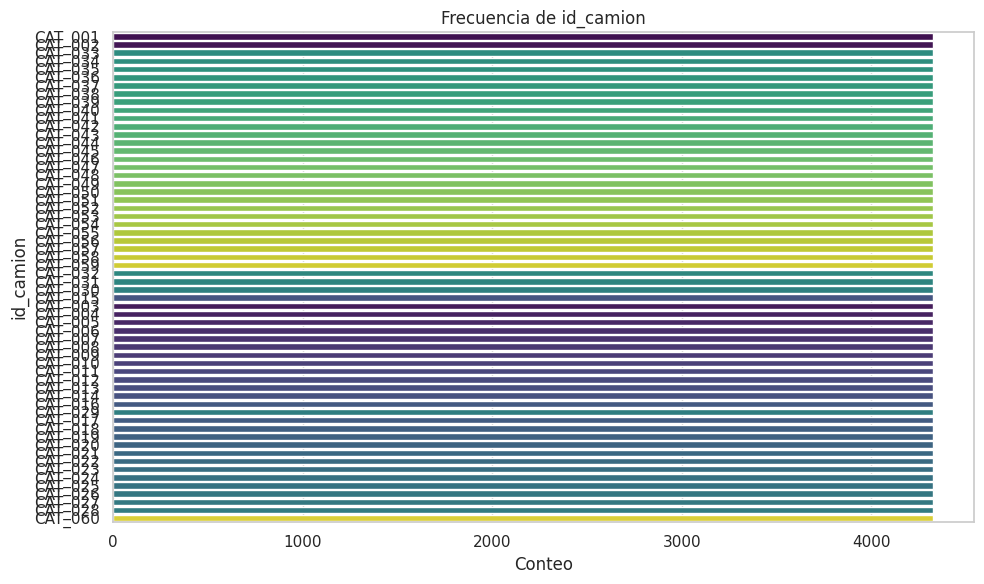

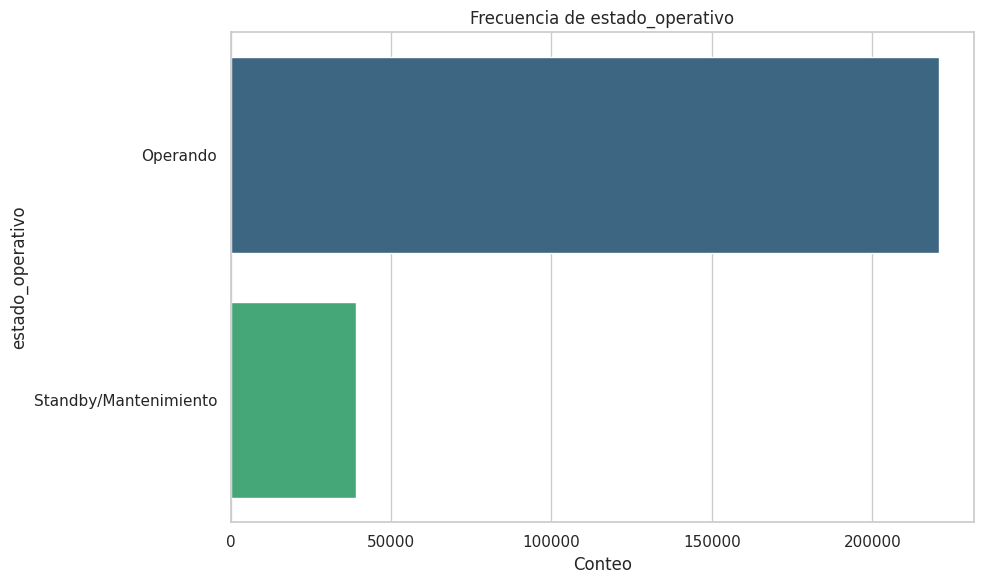

In [8]:
cat_vars = ['id_camion', 'estado_operativo']
for var in cat_vars:
    if var in df.columns:
        plt.figure(figsize=(10, 6))
        sns.countplot(y=var, data=df, order=df[var].value_counts().index, palette='viridis', hue=var, legend=False)
        plt.title(f'Frecuencia de {var}')
        plt.xlabel('Conteo')
        plt.ylabel(var)
        plt.tight_layout()
        plt.show()

### 7. Series de Tiempo
Visualización de la temperatura promedio a lo largo del tiempo.

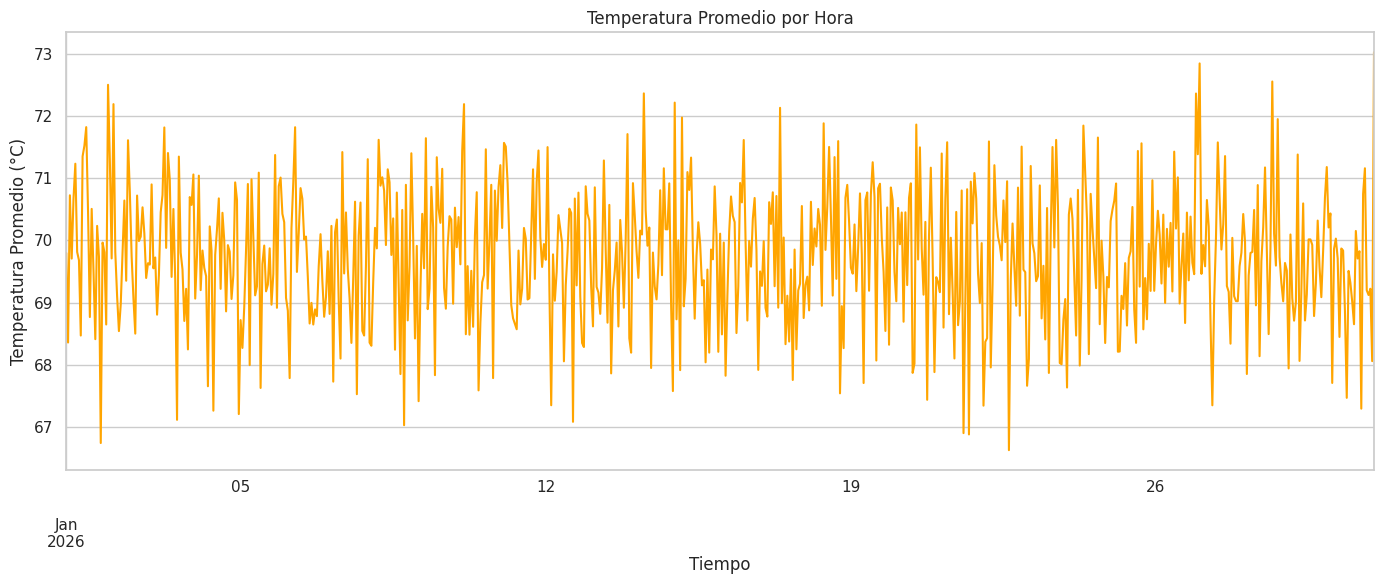

In [9]:
if 'timestamp' in df.columns and 'temperatura_c' in df.columns:
    plt.figure(figsize=(14, 6))
    df_temp = df.set_index('timestamp')
    df_temp['temperatura_c'].resample('h').mean().plot(color='orange')
    plt.title('Temperatura Promedio por Hora')
    plt.xlabel('Tiempo')
    plt.ylabel('Temperatura Promedio (°C)')
    plt.tight_layout()
    plt.show()

### 8. Zoom de Series de Tiempo (1 Día para 1 Camión)
A continuación, filtramos los datos de un camión específico para visualizar el comportamiento de variables clave (por ejemplo, velocidad y temperatura) a lo largo de un solo día.

Visualizando datos del CAT_001 para el día 2026-01-01


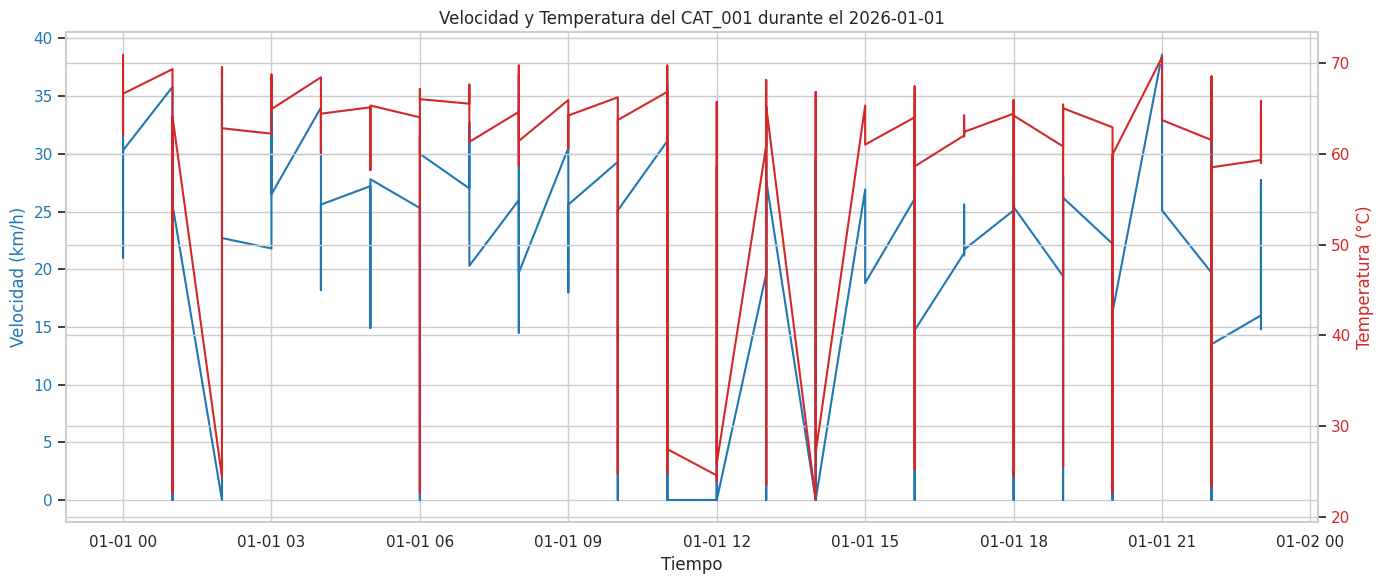

In [10]:
# Seleccionar el primer camión de la lista
camion_id = df['id_camion'].unique()[0]
df_camion = df[df['id_camion'] == camion_id].copy()

# Ordenar por timestamp para asegurar correcta visualización
df_camion = df_camion.sort_values('timestamp')

# Extraer solo un día (por ejemplo, el primer día de los datos del camión)
primer_dia = df_camion['timestamp'].dt.date.iloc[0]
df_dia = df_camion[df_camion['timestamp'].dt.date == primer_dia]

print(f"Visualizando datos del {camion_id} para el día {primer_dia}")

# Graficar Velocidad y Temperatura a lo largo del día
fig, ax1 = plt.subplots(figsize=(14, 6))

color = 'tab:blue'
ax1.set_xlabel('Tiempo')
ax1.set_ylabel('Velocidad (km/h)', color=color)
ax1.plot(df_dia['timestamp'], df_dia['velocidad_kmh'], color=color, label='Velocidad')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  # Instanciar un segundo eje que comparte el mismo eje x
color = 'tab:red'
ax2.set_ylabel('Temperatura (°C)', color=color)
ax2.plot(df_dia['timestamp'], df_dia['temperatura_c'], color=color, label='Temperatura')
ax2.tick_params(axis='y', labelcolor=color)

plt.title(f'Velocidad y Temperatura del {camion_id} durante el {primer_dia}')
fig.tight_layout()
plt.show()

### 9. Zoom Adicional: Presión de Neumáticos y Desgaste
Continuando con el análisis detallado del mismo camión y el mismo día, observaremos cómo cambian la presión de los neumáticos y el rendimiento de desgaste en el tiempo.

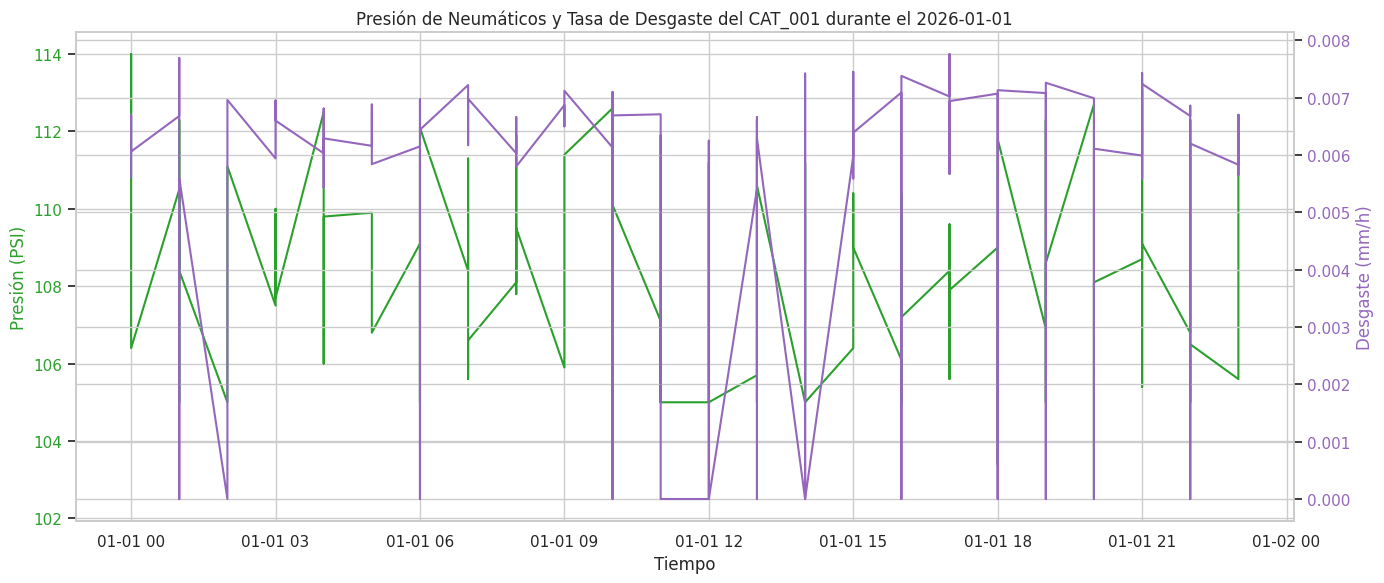

In [11]:
# Graficar Presión y Desgaste a lo largo del mismo día
fig, ax1 = plt.subplots(figsize=(14, 6))

color = 'tab:green'
ax1.set_xlabel('Tiempo')
ax1.set_ylabel('Presión (PSI)', color=color)
ax1.plot(df_dia['timestamp'], df_dia['presion_psi'], color=color, label='Presión')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  # Instanciar un segundo eje
color = 'tab:purple'
ax2.set_ylabel('Desgaste (mm/h)', color=color)
ax2.plot(df_dia['timestamp'], df_dia['desgaste_mm_h'], color=color, label='Desgaste')
ax2.tick_params(axis='y', labelcolor=color)

plt.title(f'Presión de Neumáticos y Tasa de Desgaste del {camion_id} durante el {primer_dia}')
fig.tight_layout()
plt.show()

### 10. Ubicación del Desgaste Crítico (Corte de Llantas) en la Mina
Identificamos las ubicaciones geográficas exactas y las condiciones de operación donde se registran los mayores índices de desgaste (percentil 99), lo cual indica dónde se están cortando o dañando severamente las llantas.

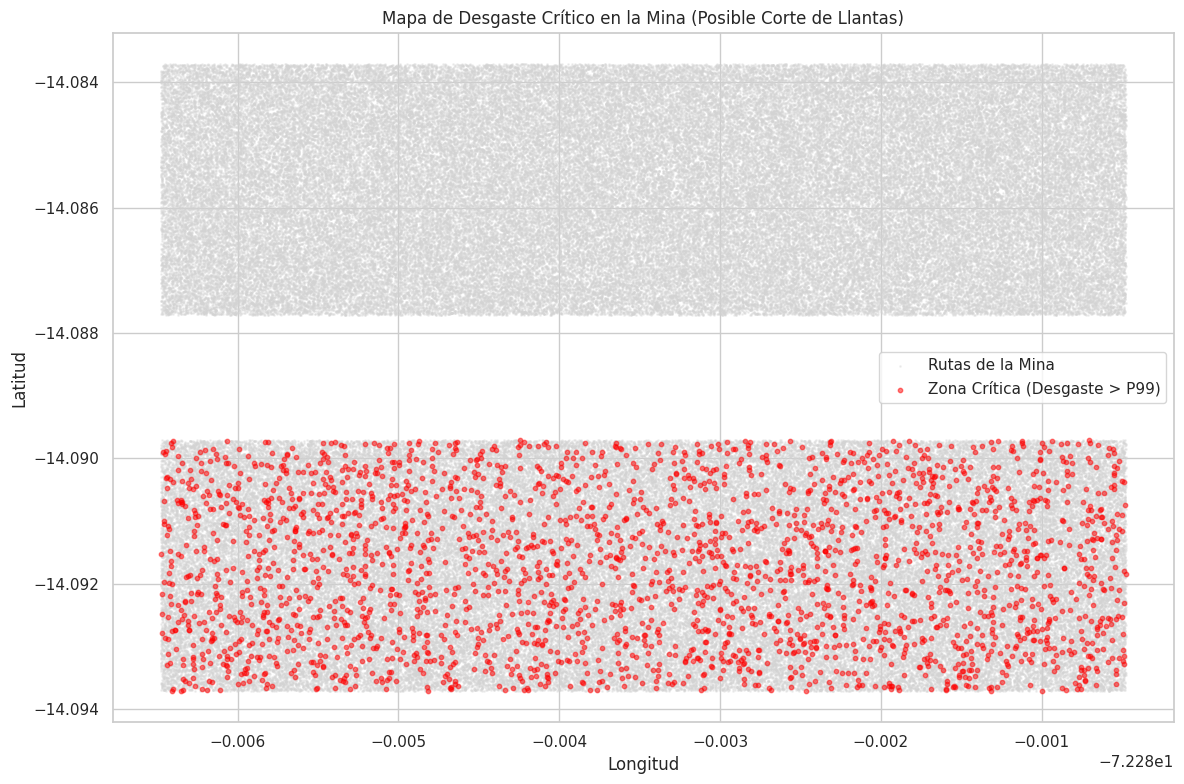

Tajo y Condiciones de Operación en Zona de Daño Crítico:
tajo_asignado      condiciones                               
Tajo_2 (Tajo Sur)  Roca 110 MPa, -10% pendiente, baja cargado    2566
Name: count, dtype: int64

Rango de Coordenadas de la Zona Crítica:
Latitud: -14.09371 a -14.08971
Longitud: -72.28647 a -72.28048


In [12]:
# Buscar el percentil 99 de desgaste
p99_desgaste = df['desgaste_mm_h'].quantile(0.99)
df_alt_desgaste = df[df['desgaste_mm_h'] > p99_desgaste]

# Graficar mapa de la mina resaltando la zona de daño crítico
plt.figure(figsize=(12, 8))
plt.scatter(df['longitud'], df['latitud'], color='lightgray', alpha=0.3, s=1, label='Rutas de la Mina')
plt.scatter(df_alt_desgaste['longitud'], df_alt_desgaste['latitud'], color='red', alpha=0.5, s=10, label='Zona Crítica (Desgaste > P99)')
plt.title('Mapa de Desgaste Crítico en la Mina (Posible Corte de Llantas)')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.legend()
plt.tight_layout()
plt.show()

# Mostrar estadísticas descriptivas de la zona
print("Tajo y Condiciones de Operación en Zona de Daño Crítico:")
print(df_alt_desgaste[['tajo_asignado', 'condiciones']].value_counts())
print("\nRango de Coordenadas de la Zona Crítica:")
print(f"Latitud: {df_alt_desgaste['latitud'].min():.5f} a {df_alt_desgaste['latitud'].max():.5f}")
print(f"Longitud: {df_alt_desgaste['longitud'].min():.5f} a {df_alt_desgaste['longitud'].max():.5f}")

### 11. Priorización de Mantenimiento y Reasignación de Camiones (Hoy Mismo)
Filtramos los datos del último reporte de telemetría de cada neumático para identificar qué camiones se encuentran en estado crítico y requieren acciones inmediatas hoy mismo:
- **Detención Inmediata:** Camiones con temperaturas de neumáticos superiores a 100°C o con múltiples neumáticos sobrecalentados (>90°C).
- **Reasignación de Tajo:** Camiones con alto desgaste acumulado que deben salir de la zona abrasiva (Tajo 2 / Sur) hacia zonas más suaves.

=== CAMIONES QUE DEBEN DETENERSE INMEDIATAMENTE (PELIGRO DE REVENTÓN) ===
id_camion  temp_max  temp_mean  llantas_sobrecalentadas
  CAT_056     103.9  83.433333                        4
  CAT_049     101.9  83.283333                        4
  CAT_047     101.6  69.183333                        1
  CAT_037     101.4  91.400000                        3
  CAT_040     100.9  88.950000                        2
  CAT_051     100.1  94.816667                        5
  CAT_031     100.0  80.066667                        2
  CAT_052      98.4  93.533333                        6
  CAT_059      97.7  93.916667                        5
  CAT_050      97.4  82.550000                        5
  CAT_034      95.3  93.000000                        6
  CAT_042      94.8  92.033333                        5

=== CAMIONES RECOMENDADOS PARA REASIGNAR FUERA DEL TAJO 2 (ALTO DESGASTE ACUMULADO) ===
id_camion  desgaste_acumulado_max  temp_max
  CAT_039                    6.62      97.2
  CAT_043            

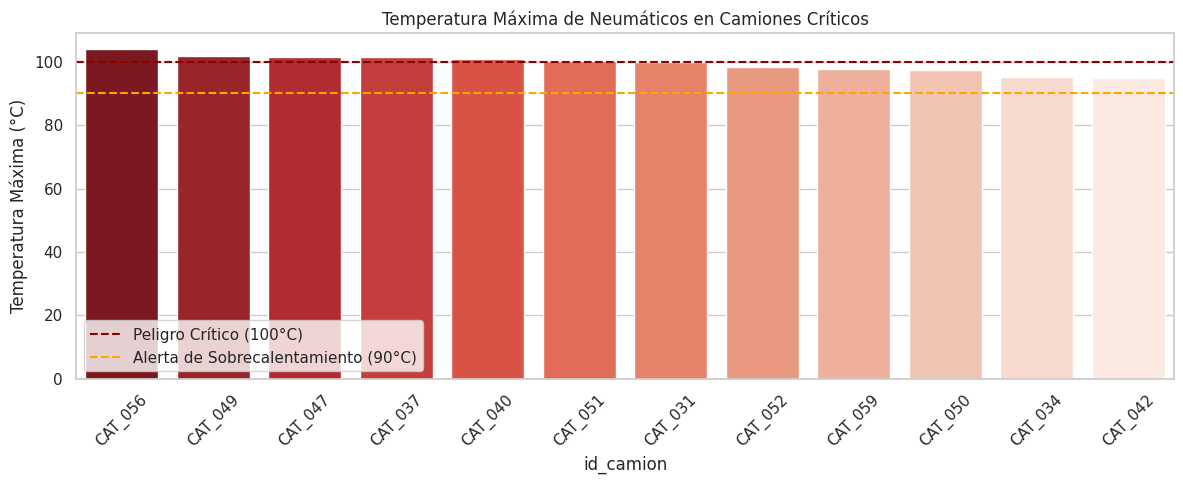

In [13]:
# Obtener los últimos registros de telemetría de cada camión/neumático
idx_ultimos = df.groupby(['id_camion', 'id_neumatico'])['timestamp'].idxmax()
df_ultimo = df.loc[idx_ultimos].copy()

# Calcular desgaste acumulado por neumático
df_ultimo['desgaste_acumulado'] = df_ultimo['profundidad_inicial_mm'] - df_ultimo['profundidad_actual_mm']

# Contar cuántos neumáticos tienen temperatura crítica (>90°C) por camión
df_ultimo['temp_critica'] = df_ultimo['temperatura_c'] > 90.0

# Agrupar por camión
resumen_camion = df_ultimo.groupby('id_camion').agg(
    temp_max=('temperatura_c', 'max'),
    temp_mean=('temperatura_c', 'mean'),
    llantas_sobrecalentadas=('temp_critica', 'sum'),
    desgaste_acumulado_max=('desgaste_acumulado', 'max'),
    tkph_max=('tkph_real', 'max')
).reset_index()

# 1. CAMIONES PARA DETENCIÓN INMEDIATA (Alta Temperatura)
detencion_inmediata = resumen_camion[
    (resumen_camion['temp_max'] >= 100.0) | (resumen_camion['llantas_sobrecalentadas'] >= 5)
].sort_values(by='temp_max', ascending=False)

print("=== CAMIONES QUE DEBEN DETENERSE INMEDIATAMENTE (PELIGRO DE REVENTÓN) ===")
print(detencion_inmediata[['id_camion', 'temp_max', 'temp_mean', 'llantas_sobrecalentadas']].to_string(index=False))

# 2. CAMIONES PARA REASIGNACIÓN (Alto Desgaste Acumulado)
# Filtrar camiones que operan en Tajo 2 (Tajo Sur) y tienen un desgaste alto acumulado (ej. > 6.5 mm)
reasignacion = resumen_camion[
    (resumen_camion['desgaste_acumulado_max'] >= 6.50) & 
    (resumen_camion['id_camion'].isin(df[df['tajo_asignado'].str.contains('Tajo_2')]['id_camion'].unique()))
].sort_values(by='desgaste_acumulado_max', ascending=False)

print("\n=== CAMIONES RECOMENDADOS PARA REASIGNAR FUERA DEL TAJO 2 (ALTO DESGASTE ACUMULADO) ===")
print(reasignacion[['id_camion', 'desgaste_acumulado_max', 'temp_max']].to_string(index=False))

# Visualizar el riesgo de temperatura extrema
plt.figure(figsize=(12, 5))
sns.barplot(x='id_camion', y='temp_max', data=detencion_inmediata, palette='Reds_r', hue='id_camion', legend=False)
plt.axhline(y=100.0, color='darkred', linestyle='--', label='Peligro Crítico (100°C)')
plt.axhline(y=90.0, color='orange', linestyle='--', label='Alerta de Sobrecalentamiento (90°C)')
plt.title('Temperatura Máxima de Neumáticos en Camiones Críticos')
plt.ylabel('Temperatura Máxima (°C)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

### 12. Análisis de Distribuciones Multimodales (Histogramas Segmentados)
Como observamos en las distribuciones iniciales, variables como la velocidad, carga (payload), presión, vibración y tasa de desgaste muestran un comportamiento multimodal (múltiples picos o picos en cero). Esto ocurre porque mezclan distintos tajos, tipos de rutas, estados de carga y velocidades operativas.

A continuación, segmentamos estas variables por sus factores clave para entender su comportamiento real.

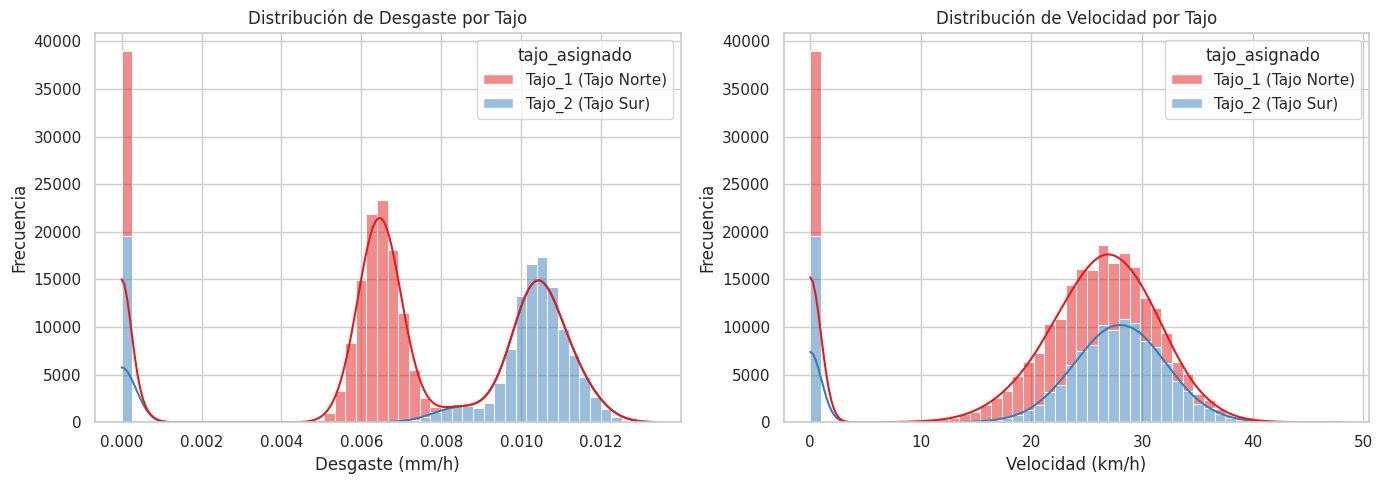

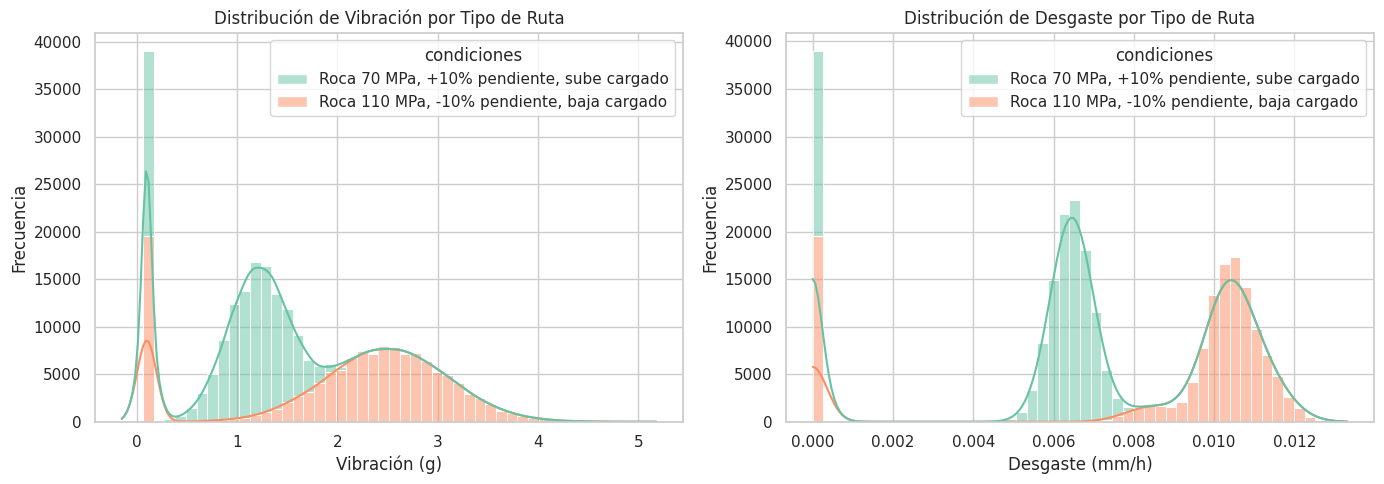

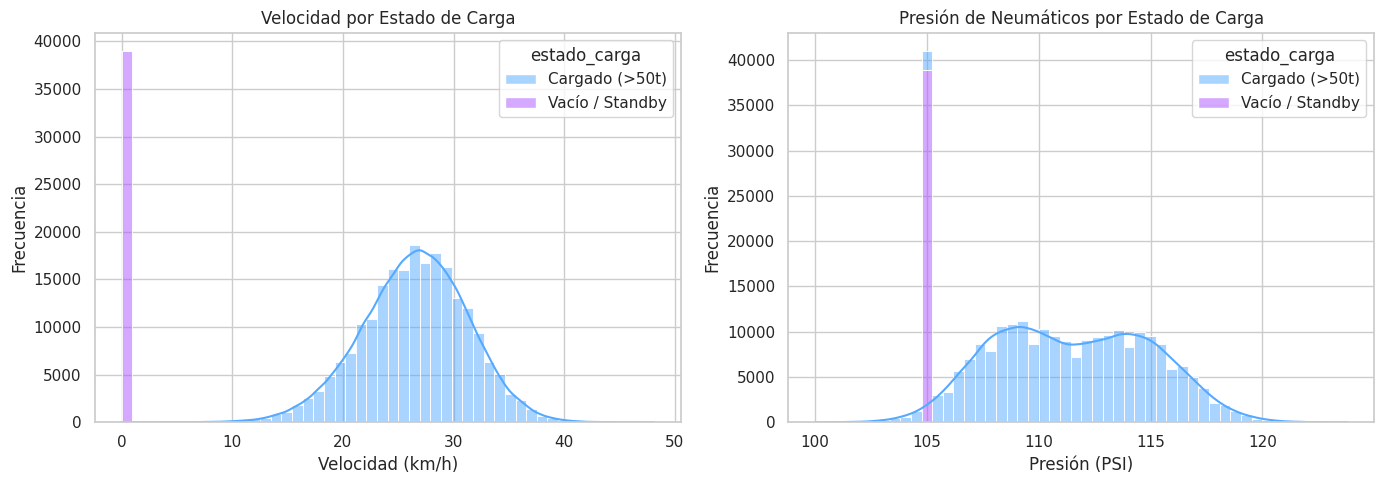

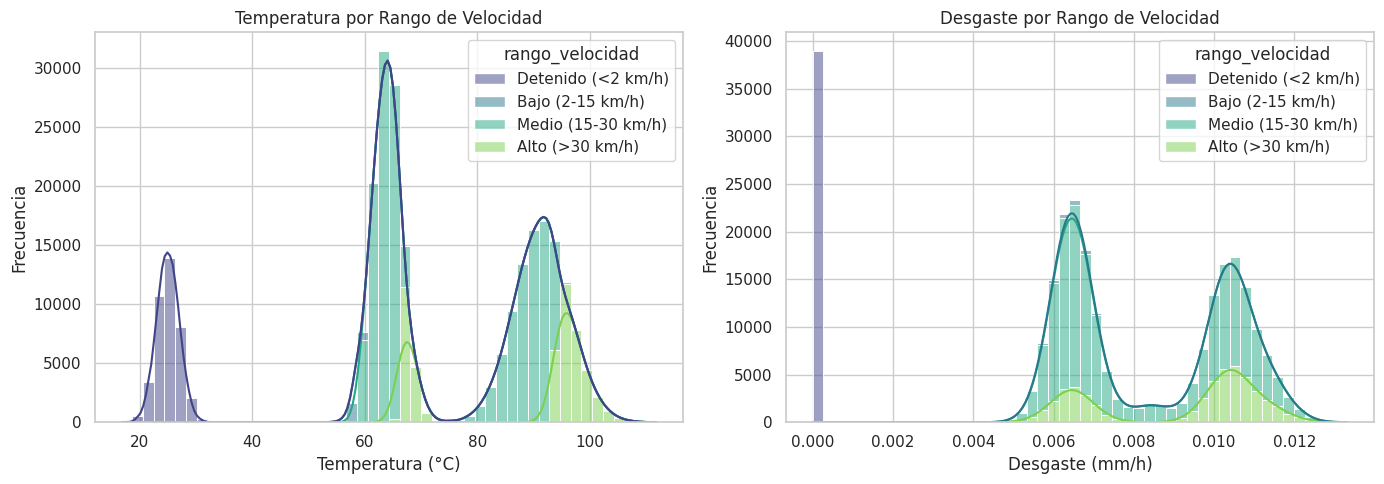

In [14]:
# Crear columnas auxiliares para segmentación
df['estado_carga'] = df['payload_ton'].apply(lambda x: 'Cargado (>50t)' if x > 50 else 'Vacío / Standby')
df['rango_velocidad'] = pd.cut(df['velocidad_kmh'], bins=[-1, 2, 15, 30, 100], labels=['Detenido (<2 km/h)', 'Bajo (2-15 km/h)', 'Medio (15-30 km/h)', 'Alto (>30 km/h)'])

# 1. Histogramas por Tajo
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
sns.histplot(data=df, x='desgaste_mm_h', hue='tajo_asignado', kde=True, bins=50, multiple='stack', palette='Set1')
plt.title('Distribución de Desgaste por Tajo')
plt.xlabel('Desgaste (mm/h)')
plt.ylabel('Frecuencia')

plt.subplot(1, 2, 2)
sns.histplot(data=df, x='velocidad_kmh', hue='tajo_asignado', kde=True, bins=50, multiple='stack', palette='Set1')
plt.title('Distribución de Velocidad por Tajo')
plt.xlabel('Velocidad (km/h)')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

# 2. Histogramas por Tipo de Ruta (Condiciones)
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
sns.histplot(data=df, x='vibracion_g', hue='condiciones', kde=True, bins=50, multiple='stack', palette='Set2')
plt.title('Distribución de Vibración por Tipo de Ruta')
plt.xlabel('Vibración (g)')
plt.ylabel('Frecuencia')

plt.subplot(1, 2, 2)
sns.histplot(data=df, x='desgaste_mm_h', hue='condiciones', kde=True, bins=50, multiple='stack', palette='Set2')
plt.title('Distribución de Desgaste por Tipo de Ruta')
plt.xlabel('Desgaste (mm/h)')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

# 3. Histogramas por Carga (Payload)
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
sns.histplot(data=df, x='velocidad_kmh', hue='estado_carga', kde=True, bins=50, multiple='stack', palette='cool')
plt.title('Velocidad por Estado de Carga')
plt.xlabel('Velocidad (km/h)')
plt.ylabel('Frecuencia')

plt.subplot(1, 2, 2)
sns.histplot(data=df, x='presion_psi', hue='estado_carga', kde=True, bins=50, multiple='stack', palette='cool')
plt.title('Presión de Neumáticos por Estado de Carga')
plt.xlabel('Presión (PSI)')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

# 4. Histogramas por Rango de Velocidad
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
sns.histplot(data=df, x='temperatura_c', hue='rango_velocidad', kde=True, bins=50, multiple='stack', palette='viridis')
plt.title('Temperatura por Rango de Velocidad')
plt.xlabel('Temperatura (°C)')
plt.ylabel('Frecuencia')

plt.subplot(1, 2, 2)
sns.histplot(data=df, x='desgaste_mm_h', hue='rango_velocidad', kde=True, bins=50, multiple='stack', palette='viridis')
plt.title('Desgaste por Rango de Velocidad')
plt.xlabel('Desgaste (mm/h)')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

In [ ]:
#

### Distribución de Temperatura por Zona (Tajo Norte vs Tajo Sur)
Analizamos la distribución de la temperatura de los neumáticos según la zona de operación.

/tmp/ipykernel_1946013/1271094068.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='tajo_asignado', y='temperatura_c', palette='Set2')


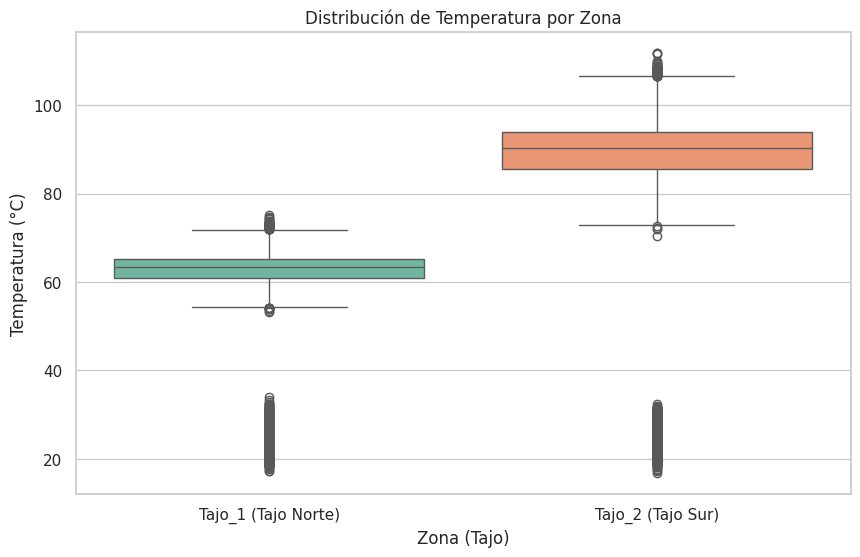

In [15]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='tajo_asignado', y='temperatura_c', palette='Set2')
plt.title('Distribución de Temperatura por Zona')
plt.xlabel('Zona (Tajo)')
plt.ylabel('Temperatura (°C)')
plt.show()

### 3.1.2 Tasa de Desgaste y CPH por Camión y Zona

In [17]:
import pandas as pd
import numpy as np

# 1. Agrupación por Tajo y cálculo de valores reales de desgaste y CPH
resumen_zona = df.groupby('tajo_asignado').agg(
    desgaste_promedio_mm_h=('desgaste_mm_h', 'mean'),
    profundidad_inicial=('profundidad_inicial_mm', 'mean'),
    cph_promedio=('cph_actual', 'mean'),
    vida_util_horas=('vida_util_proyectada_horas', 'mean'),
    horas_acumuladas=('horas_trabajadas_acumuladas', 'mean')
).reset_index()

# Extraer filas por zona
norte = resumen_zona[resumen_zona['tajo_asignado'].str.contains('Norte')].iloc[0]
sur = resumen_zona[resumen_zona['tajo_asignado'].str.contains('Sur')].iloc[0]

# Cálculos adicionales de días restantes a nivel de flota por zona
df['dias_restantes'] = (df['vida_util_proyectada_horas'] - df['horas_trabajadas_acumuladas']) / 24
std_dias_norte = df[df['tajo_asignado'].str.contains('Norte')]['dias_restantes'].std()
std_dias_sur = df[df['tajo_asignado'].str.contains('Sur')]['dias_restantes'].std()

# 2. Tabla comparativa construida dinámicamente con los datos reales
tabla_dinamica = pd.DataFrame({
    'Parámetro': [
        'Desgaste promedio (mm/h)',
        'Profundidad inicial (mm)',
        'Cocada mínima (mm)',
        'CPH promedio (USD/h)',
        'Sobrecosto diferencial (USD/h)',
        'Días restantes promedio'
    ],
    'Tajo Norte': [
        f"{norte['desgaste_promedio_mm_h']:.5f}",
        f"{norte['profundidad_inicial']:.2f}",
        '5.00',  # Valor estándar operativo constante
        f"${norte['cph_promedio']:.2f}",
        '---',
        f"{(norte['vida_util_horas'] - norte['horas_acumuladas']) / 24:.1f} ± {std_dias_norte:.1f} días"
    ],
    'Tajo Sur': [
        f"{sur['desgaste_promedio_mm_h']:.5f}",
        f"{sur['profundidad_inicial']:.2f}",
        '5.00',
        f"${sur['cph_promedio']:.2f}",
        f"+${max(0, sur['cph_promedio'] - norte['cph_promedio']):.2f}" if sur['cph_promedio'] > norte['cph_promedio'] else f"-${max(0, norte['cph_promedio'] - sur['cph_promedio']):.2f}",
        f"{(sur['vida_util_horas'] - sur['horas_acumuladas']) / 24:.1f} ± {std_dias_sur:.1f} días"
    ]
})

print("--- Tabla de Referencia Dinámica basada en Datos Reales ---")
display(tabla_dinamica)


--- Tabla de Referencia Dinámica basada en Datos Reales ---


,Parámetro,Tajo Norte,Tajo Sur
0,Desgaste promedio (mm/h),0.00549,0.00881
1,Profundidad inicial (mm),65.00,65.00
2,Cocada mínima (mm),5.00,5.00
3,CPH promedio (USD/h),$8.39,$10.83
4,Sobrecosto diferencial (USD/h),---,+$2.44
5,Días restantes promedio,245.6 ± 7.4 días,187.3 ± 7.4 días
